# 03 — Cash Flow Forecast

**Purpose:** Derive monthly net cash flow from category aggregates, select the
appropriate forecasting method by data length, produce a 12-month forecast with
80%/95% confidence intervals, compute runway, and inspect results.
Save output to `data/interim/cashflow_forecast.parquet`.

**Inputs:** `data/interim/monthly_aggregates.parquet`  
**Outputs:** `data/interim/cashflow_forecast.parquet`

**Method selection logic:**
- ≥ 24 months of history → **Prophet** (built-in uncertainty intervals)
- 12–23 months → **Holt-Winters** (bootstrapped residuals)
- < 12 months → **Rolling mean** (no CI, indicative only)

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

from src.utils.logging_config import setup_notebook_logging
from src.analysis.cashflow_forecast import select_and_run_forecast, compute_runway
from src.storage.local_writer import LocalWriter

logger = setup_notebook_logging()
writer = LocalWriter(project_root="..")


In [2]:
# ── CONFIGURE: categories to exclude from all forecasts ──────────────────────
# Add one-off or non-recurring category names here. They are removed from the
# net cashflow series, the deposits/withdrawals split, and all forecast inputs.
# Example: ["Wedding", "Car purchase"]
EXCLUDE_CATEGORIES: list[str] = [
    # "Wedding",
]
# ──────────────────────────────────────────────────────────────────────────────


## Step 1 — Derive monthly net cash flow

Sum all category amounts per month (transfers already excluded in `monthly_aggregates`).
The result is one net cash flow value per month (income − expenses).

In [3]:
df_monthly = writer.load_interim("monthly_aggregates")

# Apply category exclusion — removes one-off / non-recurring categories
if EXCLUDE_CATEGORIES:
    excluded = df_monthly[df_monthly["category"].isin(EXCLUDE_CATEGORIES)]
    excluded_sum = excluded["total_amount"].sum()
    print(f"Excluding {len(EXCLUDE_CATEGORIES)} categor(ies): {EXCLUDE_CATEGORIES}")
    print(f"Excluded total across all months: {excluded_sum:+.0f} PLN")
    df_monthly = df_monthly[~df_monthly["category"].isin(EXCLUDE_CATEGORIES)].copy()

# Net cash flow = sum across all (non-excluded) categories per month
net_monthly = (
    df_monthly.groupby("year_month")["total_amount"]
    .sum()
    .reset_index()
    .rename(columns={"total_amount": "net_cashflow"})
    .sort_values("year_month")
)

# Convert year_month string to DatetimeIndex for forecasting
net_monthly["ds"] = pd.to_datetime(net_monthly["year_month"] + "-01")
cashflow_series = net_monthly.set_index("ds")["net_cashflow"]

print(f"Months of history: {len(cashflow_series)}")
print(f"Date range: {cashflow_series.index.min().date()} → {cashflow_series.index.max().date()}")
print(f"Mean net cash flow: {cashflow_series.mean():.0f} | Std: {cashflow_series.std():.0f}")


2026-03-30 14:03:50 | src.storage.local_writer       | INFO     | Loaded 1639 rows from C:\Users\mkkom\MMEXtend\data\interim\monthly_aggregates.parquet


Months of history: 103
Date range: 2017-09-01 → 2026-03-01
Mean net cash flow: 5007 | Std: 7051


## Step 2 — Historical net cash flow — visual sanity check

Verify the series looks reasonable before forecasting.
Red bars = negative months (spending exceeded income).

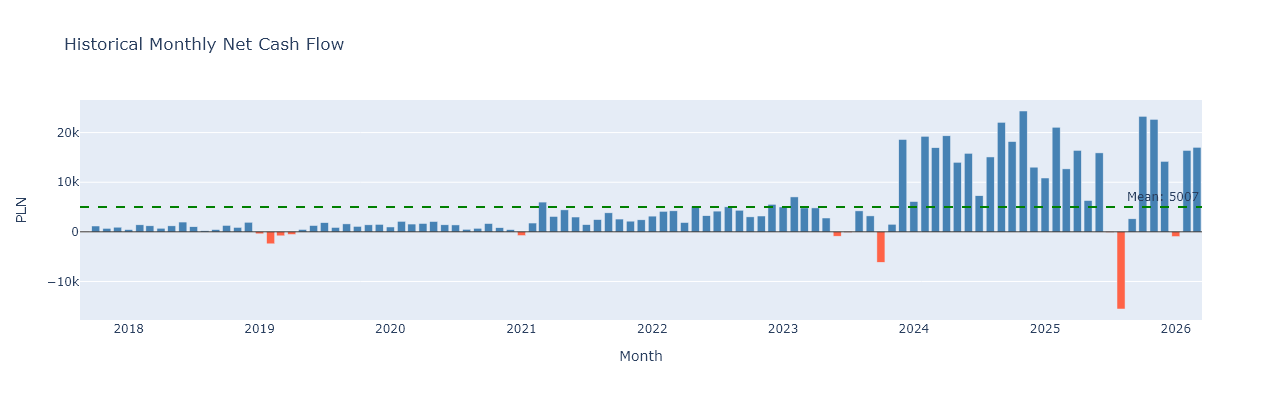

In [4]:
colors = ["steelblue" if v >= 0 else "tomato" for v in cashflow_series.values]
fig_hist = go.Figure(go.Bar(
    x=cashflow_series.index,
    y=cashflow_series.values,
    marker_color=colors,
))
fig_hist.add_hline(y=0, line_color="black", line_width=0.8)
fig_hist.add_hline(y=cashflow_series.mean(), line_color="green", line_dash="dash",
                   annotation_text=f"Mean: {cashflow_series.mean():.0f}")
fig_hist.update_layout(
    title="Historical Monthly Net Cash Flow",
    xaxis_title="Month",
    yaxis_title="PLN",
    height=400,
)
fig_hist.show()


## Step 3 — Run forecast

Method is selected automatically based on data length (63 months → Prophet).

**Assumptions:**
1. Income sources remain approximately stable
2. No major one-off events (job loss, inheritance, etc.)
3. Spending patterns continue current trajectory
4. No structural breaks in the forecast period

In [5]:
df_forecast = select_and_run_forecast(cashflow_series, periods=12)
print(f"Forecast method used: {df_forecast['method'].iloc[0]}")
print(f"Forecast periods: {len(df_forecast)}")
display(df_forecast.set_index("month").round(0).reset_index())


2026-03-30 14:03:52 | src.analysis.cashflow_forecast | INFO     | Forecast method: Prophet (103 months of history)
c:\Users\mkkom\MMEXtend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
14:03:52 - cmdstanpy - INFO - Chain [1] start processing
14:03:52 - cmdstanpy - INFO - Chain [1] done processing


Forecast method used: Prophet
Forecast periods: 12


,month,point_estimate,ci80_lower,ci80_upper,ci95_lower,ci95_upper,method
0,2026-04-01,12345.0,5802.0,19077.0,2257.0,22766.0,Prophet
1,2026-05-01,12169.0,5978.0,19803.0,1614.0,22735.0,Prophet
2,2026-06-01,12633.0,5926.0,19134.0,2308.0,22484.0,Prophet
3,2026-07-01,12776.0,5806.0,19534.0,1999.0,22492.0,Prophet
4,2026-08-01,12922.0,6440.0,20132.0,2249.0,23692.0,Prophet
5,2026-09-01,13069.0,6193.0,19427.0,2848.0,23575.0,Prophet
6,2026-10-01,13211.0,6461.0,19817.0,2989.0,22737.0,Prophet
7,2026-11-01,14757.0,8091.0,21494.0,3804.0,25606.0,Prophet
8,2026-12-01,13500.0,6247.0,21147.0,2896.0,24300.0,Prophet
9,2027-01-01,11332.0,3780.0,17958.0,433.0,22360.0,Prophet


## Step 4 — Forecast chart with CI ribbons

Key questions:
1. Is the point estimate trajectory **realistic**?
2. How wide are the CIs? (Wide = high uncertainty = don't trust)
3. Does the 80% CI bracket plausible outcomes?

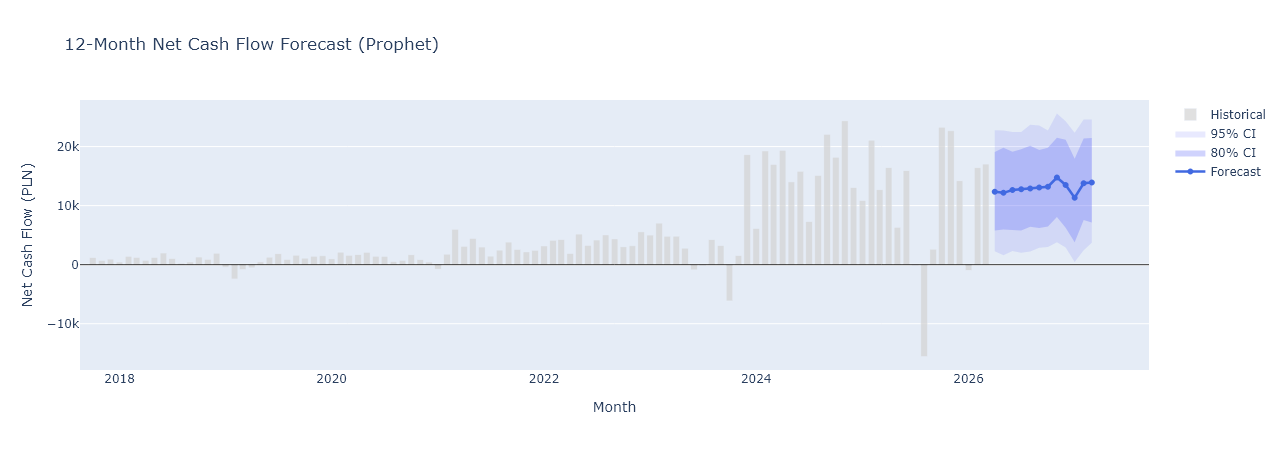

In [6]:
fig_forecast = go.Figure()

# Historical actuals
fig_forecast.add_trace(go.Bar(
    x=cashflow_series.index,
    y=cashflow_series.values,
    name="Historical",
    marker_color="lightgray",
    opacity=0.7,
))

# 95% CI ribbon
if df_forecast["ci95_lower"].notna().all():
    fig_forecast.add_trace(go.Scatter(
        x=df_forecast["month"].tolist() + df_forecast["month"].tolist()[::-1],
        y=df_forecast["ci95_upper"].tolist() + df_forecast["ci95_lower"].tolist()[::-1],
        fill="toself",
        fillcolor="rgba(99,110,250,0.15)",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI",
    ))

# 80% CI ribbon
if df_forecast["ci80_lower"].notna().all():
    fig_forecast.add_trace(go.Scatter(
        x=df_forecast["month"].tolist() + df_forecast["month"].tolist()[::-1],
        y=df_forecast["ci80_upper"].tolist() + df_forecast["ci80_lower"].tolist()[::-1],
        fill="toself",
        fillcolor="rgba(99,110,250,0.30)",
        line=dict(color="rgba(255,255,255,0)"),
        name="80% CI",
    ))

# Point estimate
fig_forecast.add_trace(go.Scatter(
    x=df_forecast["month"],
    y=df_forecast["point_estimate"],
    name="Forecast",
    line=dict(color="royalblue", width=2.5),
    mode="lines+markers",
))

fig_forecast.add_hline(y=0, line_color="black", line_width=0.8)
fig_forecast.update_layout(
    title=f"12-Month Net Cash Flow Forecast ({df_forecast['method'].iloc[0]})",
    xaxis_title="Month",
    yaxis_title="Net Cash Flow (PLN)",
    hovermode="x unified",
    height=450,
)
fig_forecast.show()

## Step 5 — CI width analysis

How wide are the confidence intervals? Wide bands = high uncertainty.
Rule of thumb: if the 80% CI width exceeds 2× the historical standard deviation,
interpret the forecast with caution.

In [7]:
if df_forecast["ci80_lower"].notna().all():
    df_forecast["ci80_width"] = df_forecast["ci80_upper"] - df_forecast["ci80_lower"]
    df_forecast["ci95_width"] = df_forecast["ci95_upper"] - df_forecast["ci95_lower"]

    hist_std = cashflow_series.std()
    mean_ci80 = df_forecast["ci80_width"].mean()

    print(f"Historical std dev:       {hist_std:.0f} PLN")
    print(f"Mean 80% CI width:        {mean_ci80:.0f} PLN")
    print(f"CI width / hist std:      {mean_ci80 / hist_std:.2f}×")
    if mean_ci80 > 2 * hist_std:
        print("⚠ CI width > 2× historical std — forecast is highly uncertain.")
    else:
        print("✓ CI width within acceptable range.")

    display(
        df_forecast[["month", "point_estimate", "ci80_lower", "ci80_upper", "ci80_width"]]
        .set_index("month").round(0).reset_index()
    )
else:
    print("No CI available (insufficient data). Forecast is indicative only.")


Historical std dev:       7051 PLN
Mean 80% CI width:        13739 PLN
CI width / hist std:      1.95×
✓ CI width within acceptable range.


,month,point_estimate,ci80_lower,ci80_upper,ci80_width
0,2026-04-01,12345.0,5802.0,19077.0,13275.0
1,2026-05-01,12169.0,5978.0,19803.0,13825.0
2,2026-06-01,12633.0,5926.0,19134.0,13208.0
3,2026-07-01,12776.0,5806.0,19534.0,13728.0
4,2026-08-01,12922.0,6440.0,20132.0,13692.0
5,2026-09-01,13069.0,6193.0,19427.0,13234.0
6,2026-10-01,13211.0,6461.0,19817.0,13357.0
7,2026-11-01,14757.0,8091.0,21494.0,13403.0
8,2026-12-01,13500.0,6247.0,21147.0,14900.0
9,2027-01-01,11332.0,3780.0,17958.0,14178.0


## Step 6 — Runway calculation

Given a current cash balance, how many months will the balance stay positive
under pessimistic / median / optimistic scenarios?

**Edit `CURRENT_BALANCE` below to reflect your actual liquid cash balance (PLN).**

In [8]:
# ── CONFIGURE: set your current liquid cash balance ───────────────────────────
CURRENT_BALANCE = 0.0  # ← edit this (PLN)
# ──────────────────────────────────────────────────────────────────────────────

if CURRENT_BALANCE == 0.0:
    print("ℹ CURRENT_BALANCE is 0.0 — set it to your actual balance for meaningful runway.")
else:
    runway = compute_runway(CURRENT_BALANCE, df_forecast)
    forecast_window = len(df_forecast)
    print(f"Forecast window: {forecast_window} months")
    print()
    for scenario, months in runway.items():
        label = scenario.replace("_months", "").capitalize()
        if months >= forecast_window:
            print(f"  {label:20s} > {forecast_window} months (balance stays positive throughout forecast)")
        else:
            print(f"  {label:20s} {months} months")

ℹ CURRENT_BALANCE is 0.0 — set it to your actual balance for meaningful runway.


## Step 7 — Save `cashflow_forecast.parquet`

Only save if the forecast looks reasonable. Stop here if something looks wrong.

In [9]:
writer.save_interim(df_forecast, "cashflow_forecast")
print("Saved: data/interim/cashflow_forecast.parquet")

2026-03-30 14:03:53 | src.storage.local_writer       | INFO     | Wrote 12 rows to C:\Users\mkkom\MMEXtend\data\interim\cashflow_forecast.parquet


Saved: data/interim/cashflow_forecast.parquet


---

## Step 8 — Deposits vs Withdrawals split

Load the monthly split computed in notebook 01.
Each row represents one month with:
- `deposits` — total income (positive)
- `withdrawals` — total outflow in absolute terms (positive)
- `disposable_income` — deposits − withdrawals (savings per month)
- `savings_rate` — disposable income / deposits

In [10]:
# Rebuild deposits/withdrawals split from the already-exclusion-filtered df_monthly.
# In monthly_aggregates, income categories have positive total_amount and
# expense categories have negative total_amount.
_dep = (
    df_monthly[df_monthly["total_amount"] > 0]
    .groupby("year_month")["total_amount"].sum().rename("deposits")
)
_wdw = (
    df_monthly[df_monthly["total_amount"] <= 0]
    .groupby("year_month")["total_amount"].sum().abs().rename("withdrawals")
)
cashflow_split = pd.concat([_dep, _wdw], axis=1).fillna(0).reset_index()
cashflow_split["disposable_income"] = cashflow_split["deposits"] - cashflow_split["withdrawals"]
cashflow_split["savings_rate"] = (
    cashflow_split["disposable_income"]
    / cashflow_split["deposits"].replace(0, float("nan"))
)
cashflow_split["ds"] = pd.to_datetime(cashflow_split["year_month"] + "-01")
cashflow_split = cashflow_split.sort_values("ds").reset_index(drop=True)

display(cashflow_split[["year_month", "deposits", "withdrawals", "disposable_income", "savings_rate"]].round(0))
print(f"\nAvg deposits:         {cashflow_split['deposits'].mean():.0f} PLN/month")
print(f"Avg withdrawals:      {cashflow_split['withdrawals'].mean():.0f} PLN/month")
print(f"Avg disposable inc.:  {cashflow_split['disposable_income'].mean():.0f} PLN/month")
print(f"Avg savings rate:     {cashflow_split['savings_rate'].mean():.1%}")

,year_month,deposits,withdrawals,disposable_income,savings_rate
0,2017-09,712.0,729.0,-17.0,-0.0
1,2017-10,2456.0,1280.0,1176.0,0.0
2,2017-11,2136.0,1439.0,697.0,0.0
3,2017-12,2319.0,1382.0,936.0,0.0
4,2018-01,2328.0,1879.0,449.0,0.0
...,...,...,...,...,...
98,2025-11,48259.0,25590.0,22669.0,0.0
99,2025-12,37257.0,23059.0,14198.0,0.0
100,2026-01,18033.0,18979.0,-946.0,-0.0
101,2026-02,40186.0,23780.0,16406.0,0.0



Avg deposits:         15330 PLN/month
Avg withdrawals:      10323 PLN/month
Avg disposable inc.:  5007 PLN/month
Avg savings rate:     25.8%


## Step 9 — Historical deposits vs withdrawals chart

Red months = disposable income was negative (withdrawals exceeded income).

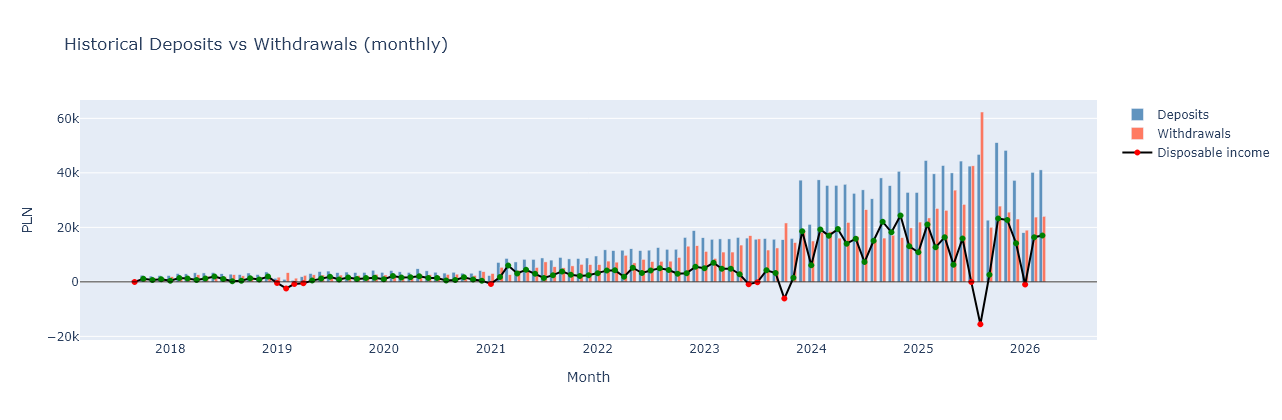

In [16]:
fig_split = go.Figure()

fig_split.add_trace(go.Bar(
    x=cashflow_split["ds"],
    y=cashflow_split["deposits"],
    name="Deposits",
    marker_color="steelblue",
    opacity=0.85,
))
fig_split.add_trace(go.Bar(
    x=cashflow_split["ds"],
    y=cashflow_split["withdrawals"],
    name="Withdrawals",
    marker_color="tomato",
    opacity=0.85,
))
# Disposable income as a line
di_colors = cashflow_split["disposable_income"].map(lambda v: "green" if v >= 0 else "red")
fig_split.add_trace(go.Scatter(
    x=cashflow_split["ds"],
    y=cashflow_split["disposable_income"],
    name="Disposable income",
    mode="lines+markers",
    line=dict(color="black", width=2),
    marker=dict(color=di_colors, size=6),
))
fig_split.add_hline(y=0, line_color="black", line_width=0.8)
fig_split.update_layout(
    title="Historical Deposits vs Withdrawals (monthly)",
    xaxis_title="Month",
    yaxis_title="PLN",
    barmode="group",
    hovermode="x unified",
    height=420,
)
fig_split.show()

## Step 10 — Forecast deposits and withdrawals separately

Run independent forecasts on:
1. The **deposits** series (income)
2. The **withdrawals** series (spend in absolute terms)

Then derive the **projected disposable income** = forecast deposits − forecast withdrawals.

The same automatic method selection applies: ≥24 months → Prophet, 12-23 → Holt-Winters, <12 → rolling mean.

In [12]:
deposits_series = cashflow_split.set_index("ds")["deposits"]
withdrawals_series = cashflow_split.set_index("ds")["withdrawals"]

df_fc_deposits = select_and_run_forecast(deposits_series, periods=12)
df_fc_withdrawals = select_and_run_forecast(withdrawals_series, periods=12)

# Projected disposable income per forecast month
df_fc_disposable = df_fc_deposits[["month"]].copy()
df_fc_disposable["deposits_forecast"]    = df_fc_deposits["point_estimate"].values
df_fc_disposable["withdrawals_forecast"] = df_fc_withdrawals["point_estimate"].values
df_fc_disposable["disposable_forecast"]  = (
    df_fc_disposable["deposits_forecast"] - df_fc_disposable["withdrawals_forecast"]
)
df_fc_disposable["savings_rate_forecast"] = (
    df_fc_disposable["disposable_forecast"]
    / df_fc_disposable["deposits_forecast"].replace(0, float("nan"))
)

print(f"Method (deposits):    {df_fc_deposits['method'].iloc[0]}")
print(f"Method (withdrawals): {df_fc_withdrawals['method'].iloc[0]}")
display(df_fc_disposable.set_index("month").round(0).reset_index())


2026-03-30 14:03:53 | src.analysis.cashflow_forecast | INFO     | Forecast method: Prophet (103 months of history)
14:03:53 - cmdstanpy - INFO - Chain [1] start processing
14:03:53 - cmdstanpy - INFO - Chain [1] done processing
2026-03-30 14:03:53 | src.analysis.cashflow_forecast | INFO     | Forecast method: Prophet (103 months of history)
14:03:53 - cmdstanpy - INFO - Chain [1] start processing
14:03:53 - cmdstanpy - INFO - Chain [1] done processing


Method (deposits):    Prophet
Method (withdrawals): Prophet


,month,deposits_forecast,withdrawals_forecast,disposable_forecast,savings_rate_forecast
0,2026-04-01,45237.0,30550.0,14686.0,0.0
1,2026-05-01,46842.0,32046.0,14796.0,0.0
2,2026-06-01,46668.0,31513.0,15155.0,0.0
3,2026-07-01,47372.0,31987.0,15385.0,0.0
4,2026-08-01,48100.0,32476.0,15624.0,0.0
5,2026-09-01,48828.0,32966.0,15862.0,0.0
6,2026-10-01,49532.0,33440.0,16092.0,0.0
7,2026-11-01,50529.0,32759.0,17770.0,0.0
8,2026-12-01,50964.0,34403.0,16561.0,0.0
9,2027-01-01,47325.0,33047.0,14278.0,0.0


## Step 11 — Deposits / Withdrawals / Disposable Income forecast chart

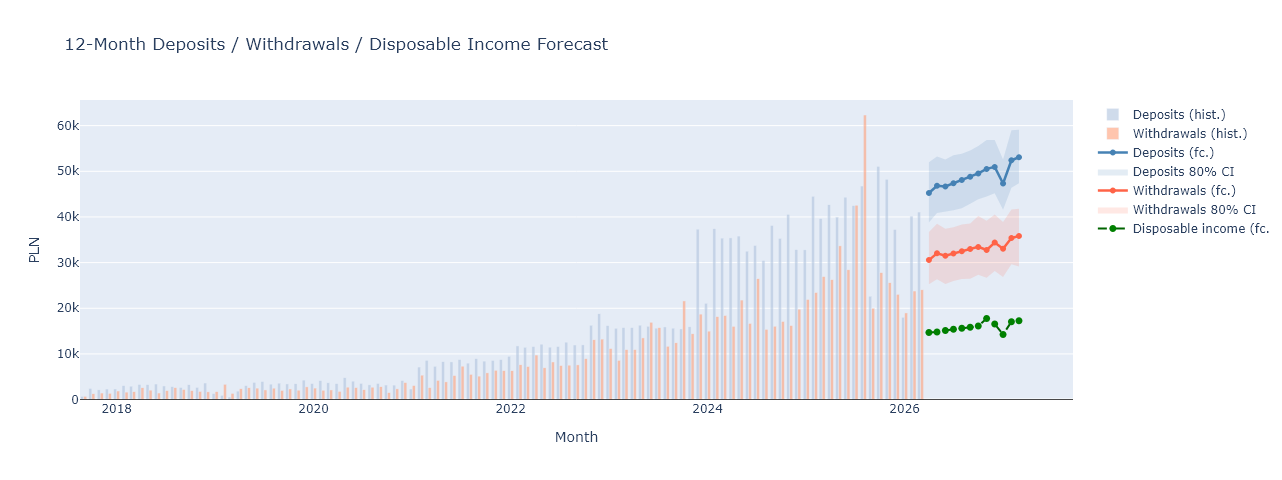

In [13]:
fig_split_fc = go.Figure()

# Historical: deposits (blue) and withdrawals (red) as light bars
fig_split_fc.add_trace(go.Bar(
    x=cashflow_split["ds"], y=cashflow_split["deposits"],
    name="Deposits (hist.)", marker_color="lightsteelblue", opacity=0.6,
))
fig_split_fc.add_trace(go.Bar(
    x=cashflow_split["ds"], y=cashflow_split["withdrawals"],
    name="Withdrawals (hist.)", marker_color="lightsalmon", opacity=0.6,
))

# Forecast: deposits
fig_split_fc.add_trace(go.Scatter(
    x=df_fc_deposits["month"], y=df_fc_deposits["point_estimate"],
    name="Deposits (fc.)", mode="lines+markers",
    line=dict(color="steelblue", width=2.5),
))
if df_fc_deposits["ci80_lower"].notna().all():
    fig_split_fc.add_trace(go.Scatter(
        x=df_fc_deposits["month"].tolist() + df_fc_deposits["month"].tolist()[::-1],
        y=df_fc_deposits["ci80_upper"].tolist() + df_fc_deposits["ci80_lower"].tolist()[::-1],
        fill="toself", fillcolor="rgba(70,130,180,0.15)",
        line=dict(color="rgba(255,255,255,0)"), name="Deposits 80% CI",
    ))

# Forecast: withdrawals
fig_split_fc.add_trace(go.Scatter(
    x=df_fc_withdrawals["month"], y=df_fc_withdrawals["point_estimate"],
    name="Withdrawals (fc.)", mode="lines+markers",
    line=dict(color="tomato", width=2.5),
))
if df_fc_withdrawals["ci80_lower"].notna().all():
    fig_split_fc.add_trace(go.Scatter(
        x=df_fc_withdrawals["month"].tolist() + df_fc_withdrawals["month"].tolist()[::-1],
        y=df_fc_withdrawals["ci80_upper"].tolist() + df_fc_withdrawals["ci80_lower"].tolist()[::-1],
        fill="toself", fillcolor="rgba(255,99,71,0.15)",
        line=dict(color="rgba(255,255,255,0)"), name="Withdrawals 80% CI",
    ))

# Forecast: disposable income
di_fc_colors = df_fc_disposable["disposable_forecast"].map(
    lambda v: "green" if v >= 0 else "red"
).tolist()
fig_split_fc.add_trace(go.Scatter(
    x=df_fc_disposable["month"], y=df_fc_disposable["disposable_forecast"],
    name="Disposable income (fc.)", mode="lines+markers",
    line=dict(color="darkgreen", width=2, dash="dash"),
    marker=dict(color=di_fc_colors, size=7),
))

fig_split_fc.add_hline(y=0, line_color="black", line_width=0.8)
fig_split_fc.update_layout(
    title="12-Month Deposits / Withdrawals / Disposable Income Forecast",
    xaxis_title="Month",
    yaxis_title="PLN",
    barmode="group",
    hovermode="x unified",
    height=480,
)
fig_split_fc.show()

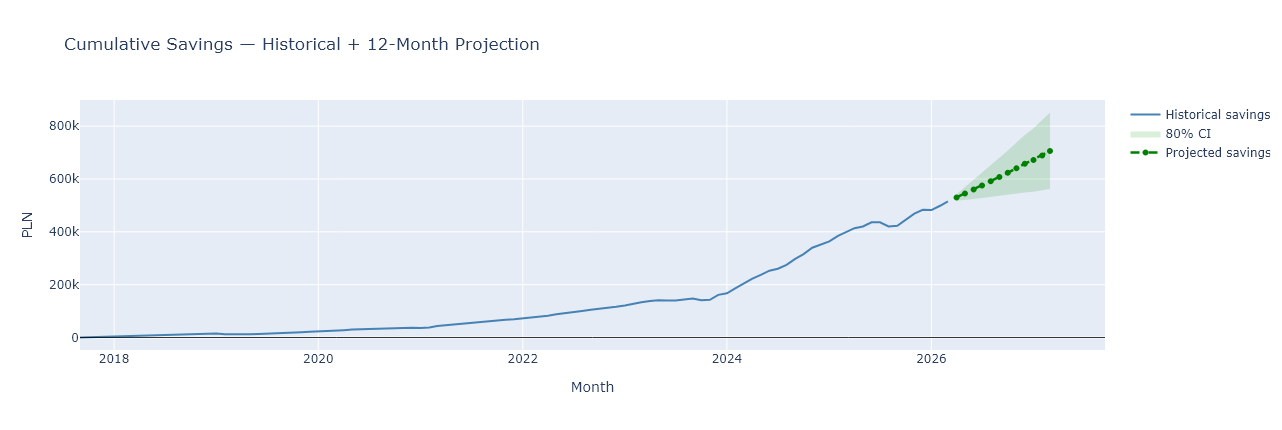

Historical savings total:    +515695 PLN
Historical savings avg/mo:   +5007 PLN

Projected new savings (12m): +190498 PLN  (median)
  Pessimistic (80% CI):      +46412 PLN
  Optimistic  (80% CI):      +335971 PLN


In [14]:
# ── CONFIGURE: starting balance for cumulative chart ─────────────────────────
# Set to your actual liquid savings / net-worth today.
# Leave as 0 to see savings accumulated since the start of tracked history.
STARTING_BALANCE = 0.0  # PLN
# ──────────────────────────────────────────────────────────────────────────────

# Historical cumulative savings from first recorded month
cum_hist = cashflow_split["disposable_income"].cumsum() + STARTING_BALANCE
last_balance = float(cum_hist.iloc[-1])

# 12-month projected cumulative savings (median + 80% CI)
cum_fc_median = df_fc_disposable["disposable_forecast"].values.cumsum() + last_balance

ci_ok = (
    df_fc_deposits["ci80_lower"].notna().all()
    and df_fc_withdrawals["ci80_upper"].notna().all()
)
if ci_ok:
    # Pessimistic: low income AND high spending
    pessimistic = (
        df_fc_deposits["ci80_lower"].values - df_fc_withdrawals["ci80_upper"].values
    ).cumsum() + last_balance
    # Optimistic: high income AND low spending
    optimistic = (
        df_fc_deposits["ci80_upper"].values - df_fc_withdrawals["ci80_lower"].values
    ).cumsum() + last_balance

fc_months = df_fc_disposable["month"]

fig_cum = go.Figure()

# Historical cumulative line
fig_cum.add_trace(go.Scatter(
    x=cashflow_split["ds"],
    y=cum_hist,
    name="Historical savings",
    line=dict(color="steelblue", width=2),
    mode="lines",
))

# 80% CI band for projected cumulative savings
if ci_ok:
    fig_cum.add_trace(go.Scatter(
        x=fc_months.tolist() + fc_months.tolist()[::-1],
        y=optimistic.tolist() + pessimistic.tolist()[::-1],
        fill="toself",
        fillcolor="rgba(0,150,0,0.15)",
        line=dict(color="rgba(255,255,255,0)"),
        name="80% CI",
    ))

# Median projected cumulative line
fig_cum.add_trace(go.Scatter(
    x=fc_months,
    y=cum_fc_median,
    name="Projected savings",
    line=dict(color="green", width=2.5, dash="dash"),
    mode="lines+markers",
))

fig_cum.add_hline(y=0, line_color="black", line_width=0.8)
fig_cum.update_layout(
    title="Cumulative Savings — Historical + 12-Month Projection",
    xaxis_title="Month",
    yaxis_title="PLN",
    hovermode="x unified",
    height=430,
)
fig_cum.show()

# ── Savings summary ───────────────────────────────────────────────────────────
proj_12m = float(df_fc_disposable["disposable_forecast"].sum())
hist_total = float(cashflow_split["disposable_income"].sum())
hist_avg = float(cashflow_split["disposable_income"].mean())

print(f"Historical savings total:    {hist_total:+.0f} PLN")
print(f"Historical savings avg/mo:   {hist_avg:+.0f} PLN")
print()
print(f"Projected new savings (12m): {proj_12m:+.0f} PLN  (median)")
if ci_ok:
    lo12 = float((df_fc_deposits["ci80_lower"].values - df_fc_withdrawals["ci80_upper"].values).sum())
    hi12 = float((df_fc_deposits["ci80_upper"].values - df_fc_withdrawals["ci80_lower"].values).sum())
    print(f"  Pessimistic (80% CI):      {lo12:+.0f} PLN")
    print(f"  Optimistic  (80% CI):      {hi12:+.0f} PLN")
if STARTING_BALANCE != 0.0:
    print(f"\nProjected balance in 12m:    {last_balance + proj_12m:+.0f} PLN  (median)")


## Step 12 — Save `cashflow_split_forecast.parquet`

In [15]:
# Combine deposit and withdrawal forecasts into one artefact
df_split_fc_full = df_fc_deposits.rename(columns={
    "point_estimate": "deposits_fc",
    "ci80_lower": "deposits_ci80_lower", "ci80_upper": "deposits_ci80_upper",
    "ci95_lower": "deposits_ci95_lower", "ci95_upper": "deposits_ci95_upper",
    "method": "method",
}).merge(
    df_fc_withdrawals[["month", "point_estimate",
                        "ci80_lower", "ci80_upper", "ci95_lower", "ci95_upper"]].rename(columns={
        "point_estimate": "withdrawals_fc",
        "ci80_lower": "withdrawals_ci80_lower", "ci80_upper": "withdrawals_ci80_upper",
        "ci95_lower": "withdrawals_ci95_lower", "ci95_upper": "withdrawals_ci95_upper",
    }),
    on="month", how="left",
)
df_split_fc_full["disposable_fc"] = (
    df_split_fc_full["deposits_fc"] - df_split_fc_full["withdrawals_fc"]
)
df_split_fc_full["savings_rate_fc"] = (
    df_split_fc_full["disposable_fc"]
    / df_split_fc_full["deposits_fc"].replace(0, float("nan"))
)

writer.save_interim(df_split_fc_full, "cashflow_split_forecast")
print("Saved: data/interim/cashflow_split_forecast.parquet")

2026-03-30 14:03:54 | src.storage.local_writer       | INFO     | Wrote 12 rows to C:\Users\mkkom\MMEXtend\data\interim\cashflow_split_forecast.parquet


Saved: data/interim/cashflow_split_forecast.parquet
